# Yes Bank Stock Closing Price Prediction using Machine Learning

## Problem Statement

Stock price prediction is an important application of Machine Learning in the financial domain. The objective of this project is to develop a regression model to predict the closing stock price of Yes Bank using historical stock price data.

The dataset contains Open, High, Low, and Close prices. By learning patterns from historical data, the machine learning model predicts the closing stock price. This project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, model building, model evaluation, and comparison of regression algorithms.

# Import Required Libraries

In this step, we import the necessary Python libraries for data manipulation, visualization, and machine learning.

- Pandas: Data manipulation
- NumPy: Numerical operations
- Matplotlib & Seaborn: Data visualization
- Scikit-learn: Machine Learning algorithms and evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load the Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function. This dataset contains historical stock prices of Yes Bank.

In [ ]:
df = pd.read_csv("/data_YesBank_StockPrices.csv")

# Display the Dataset

The first and last few rows of the dataset are displayed to verify that the data has been loaded correctly and to understand its structure.

In [ ]:
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [ ]:
df.tail()

,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


# Dataset Information

The dataset is examined to understand its dimensions, column names, data types, missing values, and statistical summary.

In [ ]:
df.shape

(185, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [ ]:
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the characteristics of the dataset, identify outliers, analyze feature distributions, and discover relationships between variables before building machine learning models.

## Distribution of Numerical Features

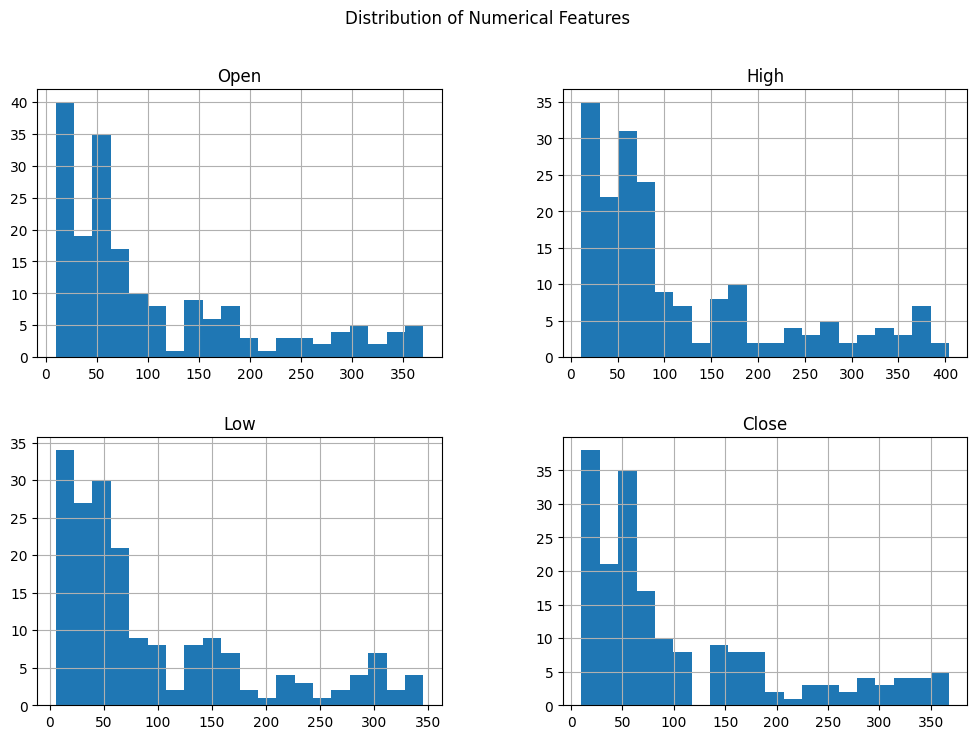

In [ ]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

## Outlier Detection using Box Plot

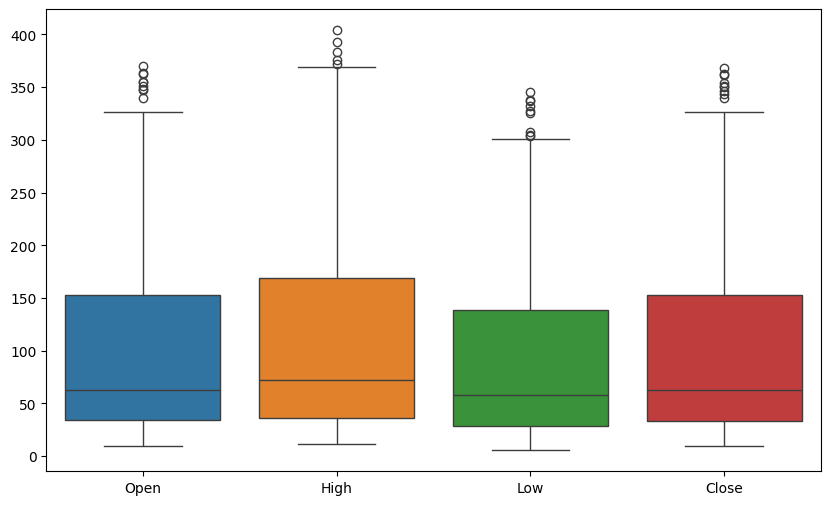

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

## Correlation Analysis

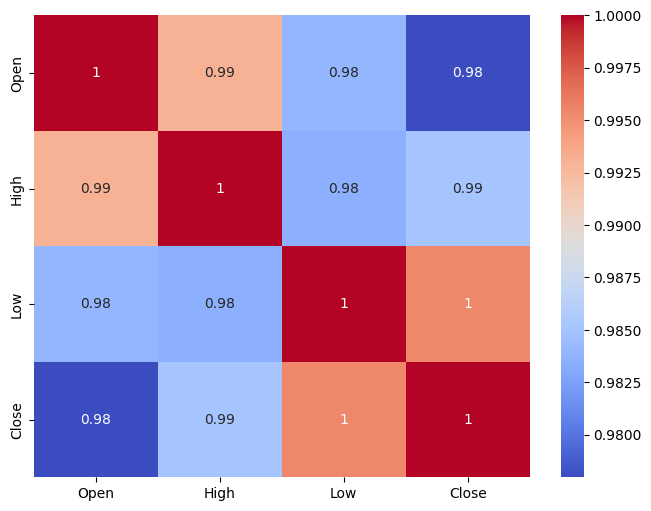

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

# Feature Selection

The input features (Open, High, and Low) are separated from the target variable (Close).

In [ ]:
X = df[['Open', 'High', 'Low']]
y = df['Close']

# Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Decision Tree
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, mae_dt, mae_rf],
    "MSE": [mse, mse_dt, mse_rf],
    "RMSE": [rmse, rmse_dt, rmse_rf],
    "R2 Score": [r2, r2_dt, r2_rf]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.812555,86.643791,9.308265,0.990414
1,Decision Tree,9.832973,257.149708,16.035888,0.971551
2,Random Forest,8.725305,190.695794,13.809265,0.978903


# Best Model Selection

Among the three regression models, the Random Forest Regressor achieved the best performance based on the evaluation metrics.

It produced the lowest prediction errors (MAE, MSE, and RMSE) and the highest R² Score, making it the most suitable model for predicting the closing stock price of Yes Bank.

# Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)
importance

,Feature,Importance
2,Low,0.718159
1,High,0.211225
0,Open,0.070616


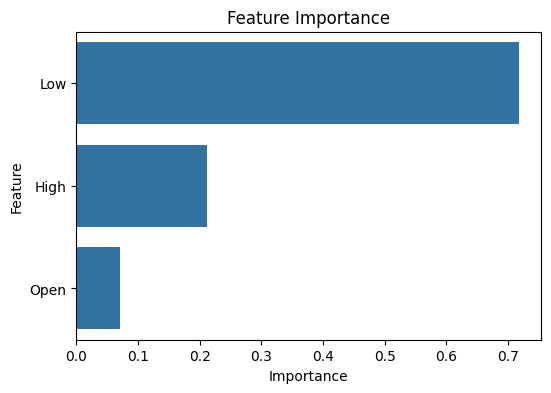

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

# Actual vs Predicted Values

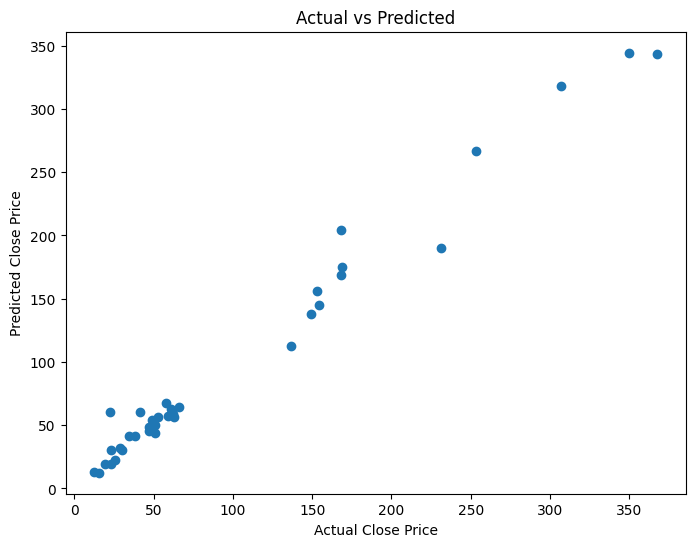

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted")
plt.show()

# Residual Analysis

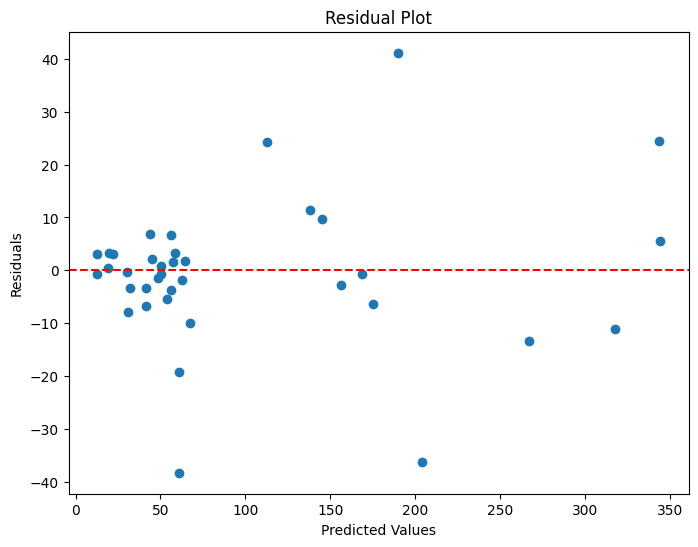

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Conclusion

This project successfully developed machine learning models to predict the closing stock price of Yes Bank.

Three regression models were trained and compared using MAE, MSE, RMSE, and R² Score. Among them, the Random Forest Regressor achieved the best performance and was selected as the final model.

# Future Scope

Future improvements include:

- Using larger and more recent stock datasets.
- Including technical indicators such as RSI and MACD.
- Applying advanced models like XGBoost and LSTM.
- Deploying the model using Flask or Streamlit for real-time prediction.